# IEEE 34 Node

In [1]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from unit_converter import UnitConverter
from fault1 import FaultSimulator
from topologia import FeederTopology
from locator1 import FaultLocator

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe')

In [44]:
DSS_FILE = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1.dss"
DSS_FILE

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe/data/34Bus/Run_IEEE34Mod1.dss')

## Aplicação da metodologia

In [45]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='800', target_kv=14.37)
simulador.topology.print_circuits_info()


🗺️  RESUMO DA TOPOLOGIA DOS CIRCUITOS MAPEADOS

C_1: L = 42.34 | Q = 4 | seçoes: [L1-L2-L3-L4]
C_2: L = 117.32 | Q = 8 | seçoes: [L1-L2-L3-L5-L6-L24-L9-L12]
C_3: L = 167.68 | Q = 9 | seçoes: [L1-L2-L3-L5-L6-L24-L8-L10-L11]
C_4: L = 159.42 | Q = 11 | seçoes: [L1-L2-L3-L5-L6-L24-L9-L13-L14-L15-L26]
C_5: L = 179.44 | Q = 13 | seçoes: [L1-L2-L3-L5-L6-L24-L9-L13-L14-L15-L27-L16-L28]
C_6: L = 189.21 | Q = 16 | seçoes: [L1-L2-L3-L5-L6-L24-L9-L13-L14-L15-L27-L16-L29-L17-L30-L19]
C_7: L = 189.45 | Q = 17 | seçoes: [L1-L2-L3-L5-L6-L24-L9-L13-L14-L15-L27-L16-L29-L18-L21-L22-L23]
C_8: L = 193.49 | Q = 17 | seçoes: [L1-L2-L3-L5-L6-L24-L9-L13-L14-L15-L27-L16-L29-L17-L30-L20-L31]




In [46]:
simulador.topology.get_sensor_for_line('l24')

'l5'

In [47]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [03:12<00:00,  3.39it/s]


In [48]:
localizador.df

,linha_faltosa,distancia,tipo,r,l1_ia,l1_va_r,l1_va_i,l1_ia_r,l1_ia_i,l1_ib,...,circuito_5_d,circuito_6_line,circuito_6_d,circuito_7_line,circuito_7_d,circuito_8_line,circuito_8_d,linha_estimada,dist_estimada,erro_percentual
0,l1,235.9152,at,0.0001,53783.779262,14894.631657,-140.523019,37725.583809,-38333.734987,45.411495,...,235.915190,l1,235.915190,l1,235.915190,l1,235.915190,l1,235.915190,-1.652049e-08
1,l1,235.9152,bt,0.0001,36.904127,15094.505072,-55.551640,36.803211,-2.727320,53589.114717,...,235.915183,l1,235.915183,l1,235.915183,l1,235.915183,l1,235.915183,-2.940211e-08
2,l1,235.9152,ct,0.0001,47.118937,15046.710906,27.436488,46.656758,-6.583398,34.268651,...,235.915185,l1,235.915185,l1,235.915185,l1,235.915185,l1,235.915185,-2.614308e-08
3,l1,235.9152,ab,0.0001,64380.795064,14996.585504,-345.410266,64078.873546,-6227.739400,64363.462233,...,235.915185,l1,235.915185,l1,235.915185,l1,235.915185,l1,235.915185,-2.472401e-08
4,l1,235.9152,bc,0.0001,45.365183,15094.736853,-0.231002,44.553001,-8.545751,61028.441186,...,235.915189,l1,235.915189,l1,235.915189,l1,235.915189,l1,235.915189,-1.820909e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,l30,57329.3936,act,0.0001,256.415228,15093.703499,-0.725352,190.195947,-171.971715,40.223558,...,55976.520114,l26,48591.216000,l28,54199.536024,l30,57326.248470,l30,57326.248470,-5.332920e-03
650,l30,57329.3936,abc,0.0001,262.111550,15093.901744,-1.146220,230.506983,-124.775779,277.369002,...,55976.520056,l26,41480.232865,l28,54199.536022,l30,57327.386559,l30,57327.386559,-3.403163e-03
651,l31,57940.8224,bt,0.0001,37.553239,15094.760241,-0.386456,37.172797,-5.331879,205.721903,...,57744.360000,l26,41480.233578,l28,54693.312000,l31,57938.792384,l31,57938.792384,-3.442120e-03
652,l31,58385.2208,bt,0.0001,37.623585,15094.759955,-0.385007,37.236295,-5.384464,204.140194,...,57744.360000,l26,41480.233622,l28,54693.312000,l31,58383.106361,l31,58383.106361,-3.585269e-03


In [11]:
print(localizador.df.columns)

Index(['linha_faltosa', 'distancia', 'tipo', 'r', 'l1_ia', 'l1_va_r',
       'l1_va_i', 'l1_ia_r', 'l1_ia_i', 'l1_ib',
       ...
       'circuito_5_d', 'circuito_6_line', 'circuito_6_d', 'circuito_7_line',
       'circuito_7_d', 'circuito_8_line', 'circuito_8_d', 'linha_estimada',
       'dist_estimada', 'erro_percentual'],
      dtype='object', length=248)


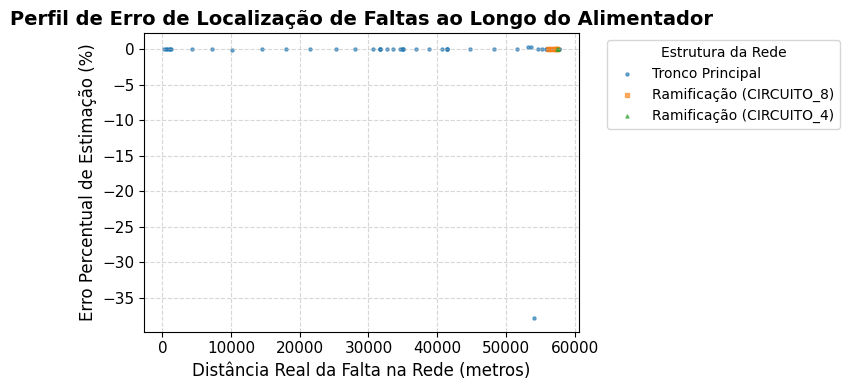

In [49]:
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'abc') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()

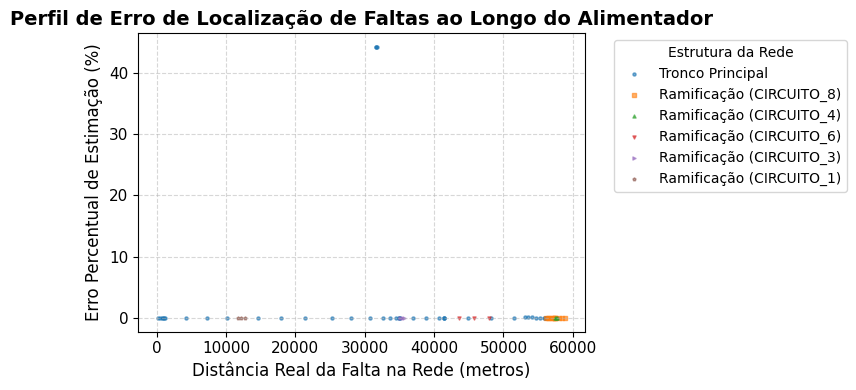

In [50]:


"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'bt') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()

In [9]:
localizador.export_results(
    output_dir= BASE_DIR / "result",
    filename= "ieee_34_node_result_50m.csv"
)

✅ Análise concluída. Resultados salvos em: C:\Users\GREI-Luis-Felipe\Documents\GitHub\tcc-luis-felipe\result\ieee_34_node_result_50m.csv


## Análise dos resultados

In [6]:
results_df = pd.read_csv(BASE_DIR / "result" / "ieee_34_node_result_50m.csv", sep=";", decimal=",")
results_df.head()

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_5_line,circuito_6_d,circuito_6_line,circuito_7_d,circuito_7_line,circuito_8_d,circuito_8_line,linha_estimada,dist_estimada,erro_percentual
0,14176.031953,-601.531341,-7328.570585,-12952.706480,-7328.288598,13192.202526,163764.037424,-177498.929473,-20.412232,-29.766292,...,l1,50.000077,l1,50.000076,l1,50.000076,l1,l1,50.000078,1.349468e-07
1,15085.867327,-248.598742,-7595.239576,-11979.652859,-7556.137927,12824.176241,37.038968,-3.123443,-235312.101775,-49969.648684,...,l1,50.000064,l1,50.000064,l1,50.000063,l1,l1,50.000066,1.139939e-07
2,14883.032194,130.806446,-7759.274793,-12941.356548,-6572.701340,12571.814313,39.403020,-4.366007,-17.697516,-28.039087,...,l1,50.000060,l1,50.000060,l1,50.000060,l1,l1,50.000061,1.049866e-07
3,14566.162418,-1482.597008,-7019.038442,-11589.948607,-7547.159834,13072.549048,278483.528904,-45598.967910,-278466.570059,45544.394987,...,l1,50.000058,l1,50.000058,l1,50.000058,l1,l1,50.000058,1.000220e-07
4,15094.713484,-0.297325,-8441.899313,-11878.511205,-6652.821071,11878.800104,56.597975,-10.213400,-181843.573912,-196137.850518,...,l1,50.000054,l1,50.000054,l1,50.000053,l1,l1,50.000054,9.347661e-08


In [8]:
results_df.columns

Index(['va_r', 'va_i', 'vb_r', 'vb_i', 'vc_r', 'vc_i', 'ia_r', 'ia_i', 'ib_r',
       'ib_i', 'ic_r', 'ic_i', 'linha_faltosa', 'distancia', 'tipo', 'r',
       'l1_ia', 'l1_ib', 'l1_ic', 'l4_ia', 'l4_ib', 'l4_ic', 'l5_ia', 'l5_ib',
       'l5_ic', 'l8_ia', 'l8_ib', 'l8_ic', 'l9_ia', 'l9_ib', 'l9_ic', 'l12_ia',
       'l12_ib', 'l12_ic', 'l13_ia', 'l13_ib', 'l13_ic', 'l26_ia', 'l26_ib',
       'l26_ic', 'l27_ia', 'l27_ib', 'l27_ic', 'l28_ia', 'l28_ib', 'l28_ic',
       'l29_ia', 'l29_ib', 'l29_ic', 'l17_ia', 'l17_ib', 'l17_ic', 'l18_ia',
       'l18_ib', 'l18_ic', 'l19_ia', 'l19_ib', 'l19_ic', 'l20_ia', 'l20_ib',
       'l20_ic', 'circuito_1_d', 'circuito_1_line', 'circuito_2_d',
       'circuito_2_line', 'circuito_3_d', 'circuito_3_line', 'circuito_4_d',
       'circuito_4_line', 'circuito_5_d', 'circuito_5_line', 'circuito_6_d',
       'circuito_6_line', 'circuito_7_d', 'circuito_7_line', 'circuito_8_d',
       'circuito_8_line', 'linha_estimada', 'dist_estimada',
       'erro_percent

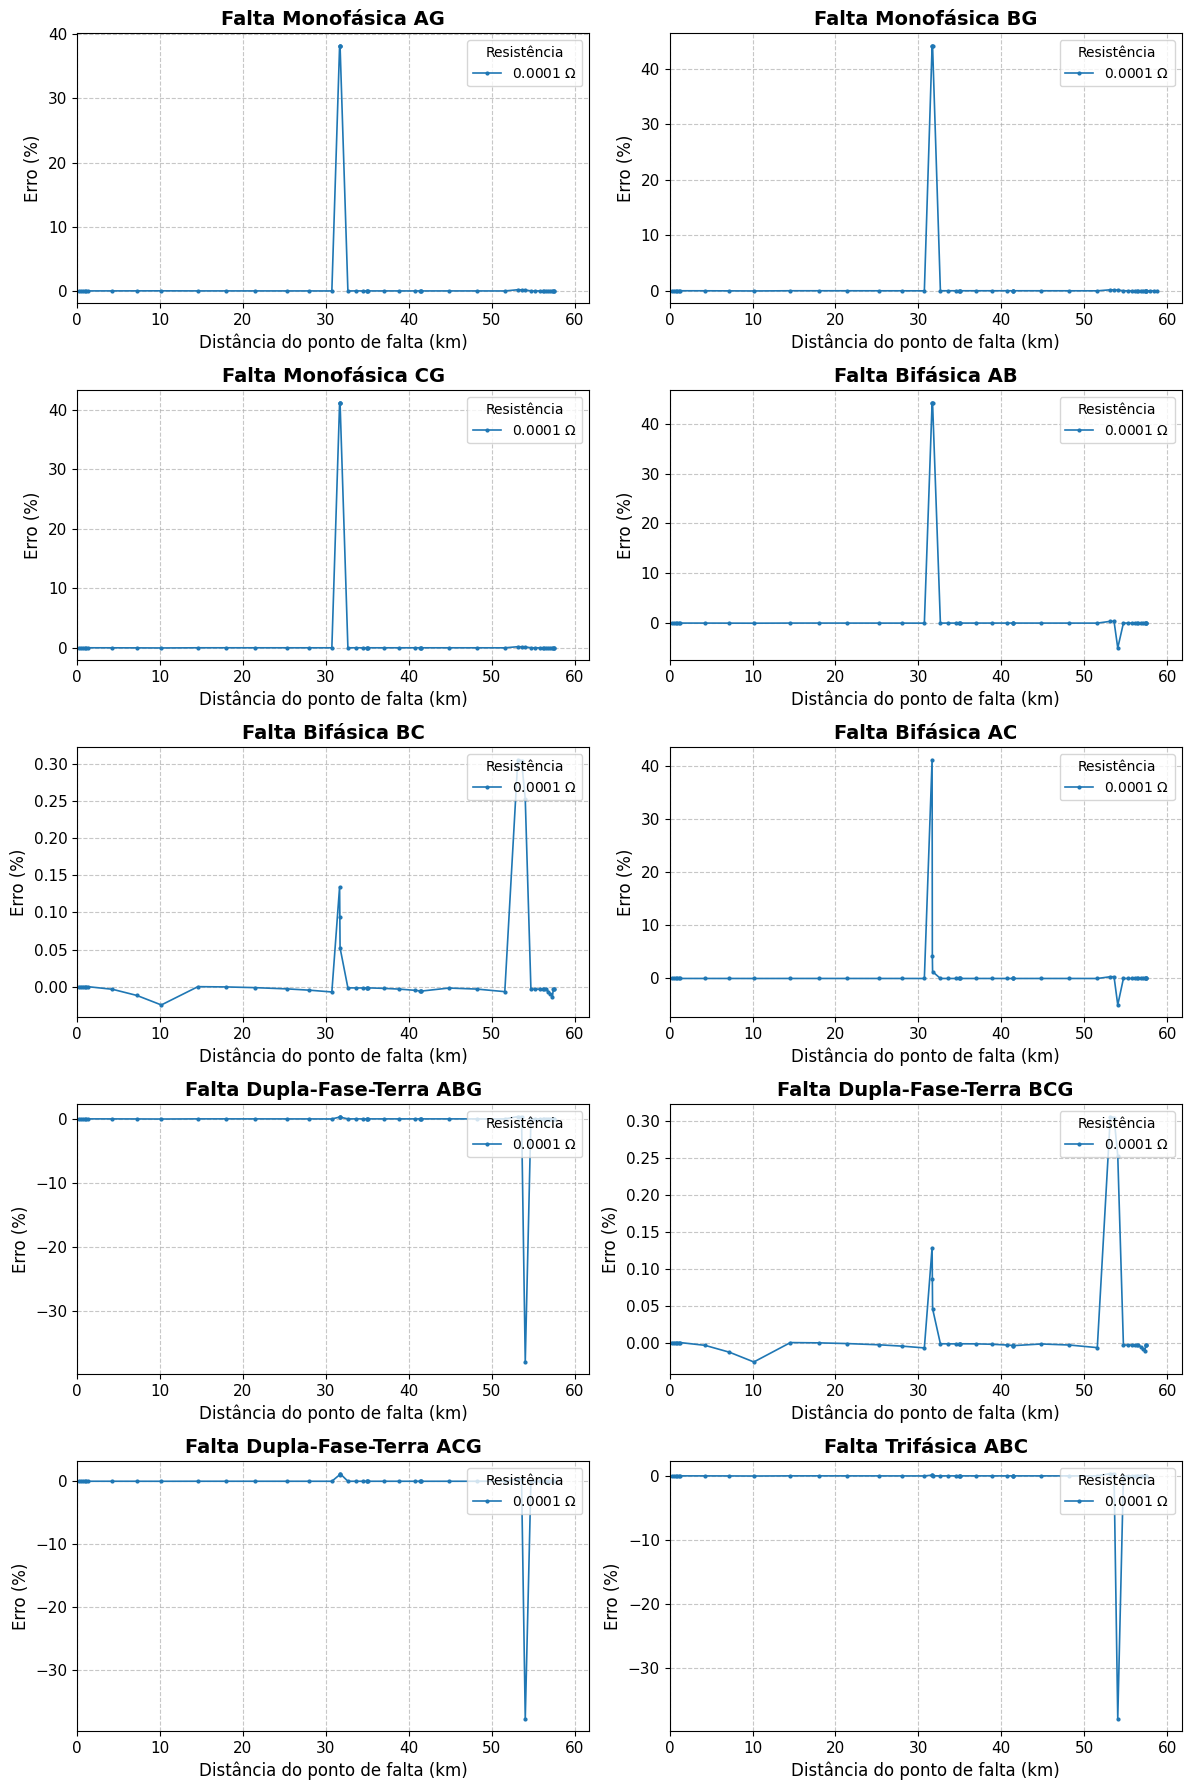

In [51]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = localizador.df.copy()

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

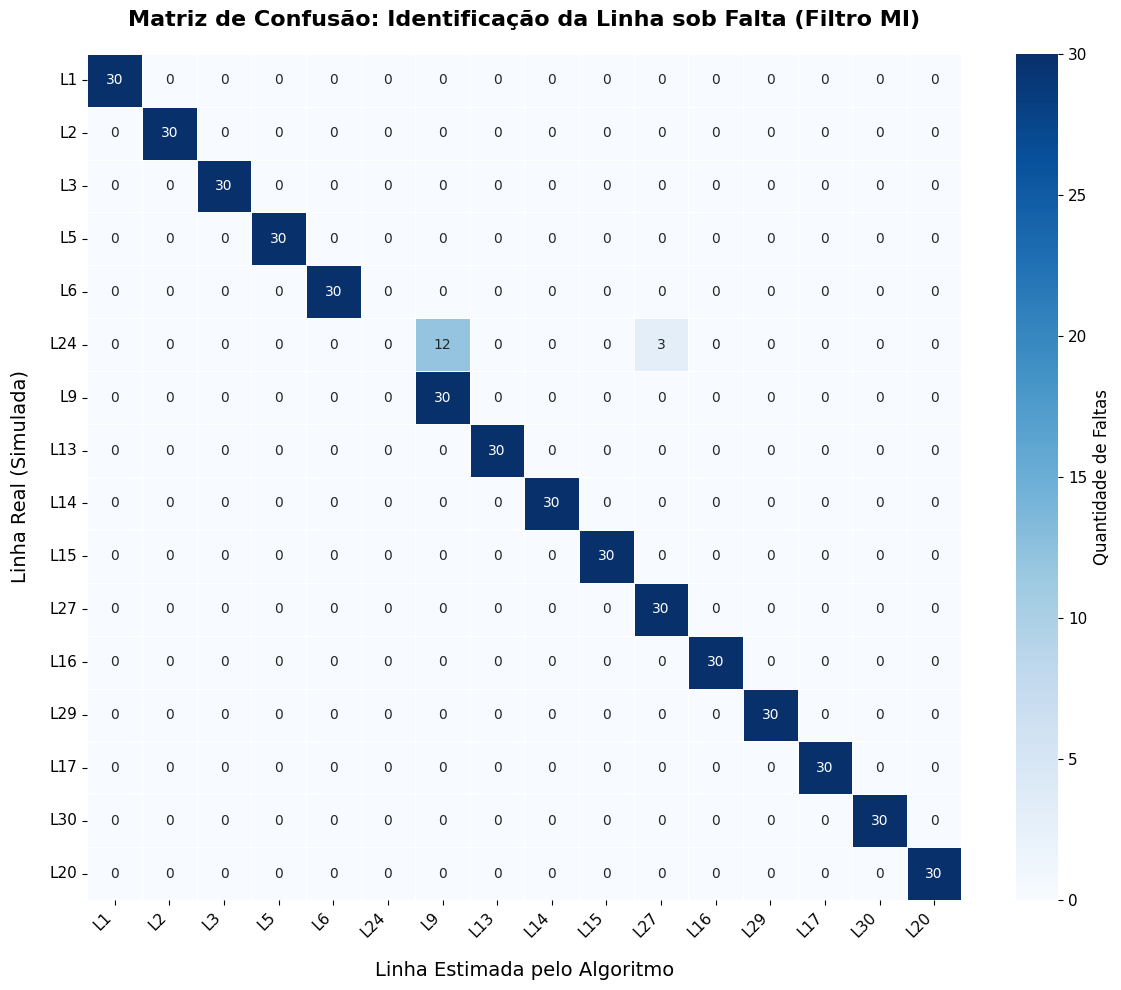

In [15]:
# Definimos o ramal principal na exata ordem topológica (da subestação para o final)
ramal_principal = ['l1', 'l2', 'l3', 'l5', 'l6', 'l24', 'l9', 'l13', 'l14', 'l15', 'l27', 'l16', 'l29', 'l17', 'l30', 'l20']

# Filtramos o DataFrame para focar apenas nas faltas ocorridas no ramal principal
# (Você pode comentar isso no futuro se quiser plotar a rede inteira)
# df_plot = df[(df['linha_faltosa'].isin(ramal_principal))].copy()

# df_plot = results_df.copy()
df_plot = localizador.df

# Removemos casos onde o algoritmo não conseguiu estimar (NaN)
df_plot = df_plot.dropna(subset=['linha_estimada'])

# Padronizamos os nomes para maiúsculas para ficar bonito no gráfico
y_true = df_plot['linha_faltosa'].str.upper()
y_pred = df_plot['linha_estimada'].str.upper()
labels_ordenados = [l.upper() for l in ramal_principal]

# --- 3. CÁLCULO DA MATRIZ DE CONFUSÃO ---
cm = confusion_matrix(y_true, y_pred, labels=labels_ordenados)

# --- 4. PLOTAGEM DO GRÁFICO ---
# Configurações de fonte global
plt.rcParams["font.family"] = "DejaVu Sans"

# Criamos uma figura grande e quadrada para acomodar os quadradinhos da matriz
plt.figure(figsize=(12, 10))

# Utilizamos o Heatmap do Seaborn (cmap='Blues' gera um degradê azul muito profissional)
# fmt='d' garante que os números apareçam inteiros e não em notação científica
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_ordenados, 
            yticklabels=labels_ordenados,
            linewidths=.5, cbar_kws={'label': 'Quantidade de Faltas'})

# Estética
plt.title("Matriz de Confusão: Identificação da Linha sob Falta (Filtro MI)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Linha Estimada pelo Algoritmo", fontsize=14, labelpad=15)
plt.ylabel("Linha Real (Simulada)", fontsize=14, labelpad=15)

# Rotaciona os rótulos para melhor leitura
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

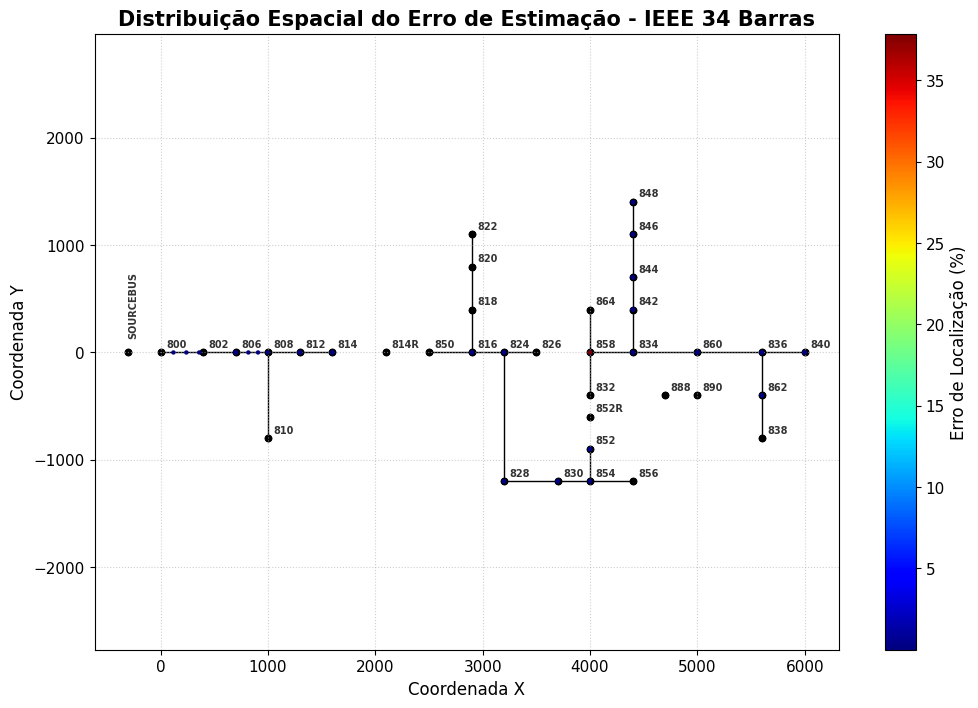

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CARREGAMENTO DOS DADOS ---
# Coordenadas das barras (enviadas por você)
df_coords = pd.read_csv(BASE_DIR / "data" / "34Bus" / "IEEE34_BusXY.csv", header=None, names=['Bus', 'X', 'Y'])
coords = {str(row['Bus']).lower(): (row['X'], row['Y']) for _, row in df_coords.iterrows()}

# Resultados da simulação (gerados anteriormente)
# df_res = pd.read_csv('result/localizacao_filtrada.csv', sep=';', decimal=',')

# --- 2. CONFIGURAÇÃO DO PLOT ---
plt.figure(figsize=(12, 8))
plt.rcParams["font.family"] = "DejaVu Sans"

# --- 3. DESENHAR A ESTRUTURA DA REDE (LINHAS CINZAS) ---
# Usamos a topologia mapeada para saber quem conecta com quem
for line_name, info in simulador.topology.line_data.items():
    b1, b2 = info['bus1'], info['bus2']
    if b1 in coords and b2 in coords:
        x_values = [coords[b1][0], coords[b2][0]]
        y_values = [coords[b1][1], coords[b2][1]]
        # plt.plot(x_values, y_values, color='lightgray', linewidth=1, zorder=1)
        plt.plot(x_values, y_values, color='black', linewidth=1, zorder=1)

bus_x = [coord[0] for coord in coords.values()]
bus_y = [coord[1] for coord in coords.values()]
plt.scatter(bus_x, bus_y, color='black', s=20, zorder=1, label='Barras (Nós)')

# --- 3.2 Desenhar as Barras/Nós ---
barras_rotacionadas = ['sourcebus']

for bus_name, (bx, by) in coords.items():
    # Desenha o ponto da barra
    plt.scatter(bx, by, color='black', s=20, zorder=1)
    
    rotacao = 0
    deslocamento_x = 50
    deslocamento_y = 50

    if bus_name in barras_rotacionadas:
        rotacao = 90
        # Dica: Quando você rotaciona o texto, às vezes ele fica em cima da linha.
        # Você pode ajustar o deslocamento X e Y especificamente para elas:
        deslocamento_x = 0
        deslocamento_y = 150

    # Adiciona o nome da barra com um pequeno deslocamento (ex: +50 unidades em X e Y)
    # ha='left' e va='bottom' ajudam a posicionar o texto para fora do ponto
    plt.text(bx + deslocamento_x, by + deslocamento_y, bus_name.upper(), 
             fontsize=7, 
             fontweight='bold',
             color='black',
             alpha=0.8,
             zorder=1,
             rotation=rotacao)

# Adiciona uma entrada manual na legenda para as barras, se desejar
plt.scatter([], [], color='black', s=40, label='Barras (Nós)')

# --- 4. PLOTAR OS ERROS (HEATMAP DE PONTOS) ---
results_df = localizador.df.copy()
# Vamos filtrar um tipo de falta e uma resistência para o mapa não ficar poluído
df_mapa = results_df[(results_df['tipo'] == 'abc') & (results_df['r'] == 0.0001)].copy()

x_faltas, y_faltas, erros = [], [], []

for _, row in df_mapa.iterrows():
    line_name = row['linha_faltosa']
    # Precisamos do 'm' (percentual) que gerou essa falta
    # Se não salvou o 'm', podemos estimar: m = (dist_falta - dist_bus1) / comprimento_linha
    line_info = simulador.topology.line_data[line_name]
    b1, b2 = line_info['bus1'], line_info['bus2']
    
    if b1 in coords and b2 in coords:
        # Recuperamos o m do loop original ou calculamos pela distância
        dist_b1_km = UnitConverter.to_km(simulador.buses_distance[b1], simulador.units)
        dist_b1_m = dist_b1_km * 1000.0

        length_km = UnitConverter.to_km(line_info['length'], simulador.units)
        line_length_m = length_km * 1000.0

        m = (row['distancia'] - dist_b1_m) / line_length_m # Exemplo de ajuste de escala
        m = np.clip(m, 0, 1) # Garante que fique dentro da linha

        xf = coords[b1][0] + m * (coords[b2][0] - coords[b1][0])
        yf = coords[b1][1] + m * (coords[b2][1] - coords[b1][1])
        
        x_faltas.append(xf)
        y_faltas.append(yf)
        erros.append(abs(row['erro_percentual']))

# Criar o scatter plot colorido pelo erro
sc = plt.scatter(x_faltas, y_faltas, c=erros, cmap='jet', s=10, edgecolors='none', zorder=2)

# --- 5. ESTÉTICA E BARRA DE CORES ---
cbar = plt.colorbar(sc)
cbar.set_label('Erro de Localização (%)', fontsize=12)

plt.title('Distribuição Espacial do Erro de Estimação - IEEE 34 Barras', fontsize=15, fontweight='bold')
plt.xlabel('Coordenada X', fontsize=12)
plt.ylabel('Coordenada Y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Mantém a proporção da rede

plt.show()

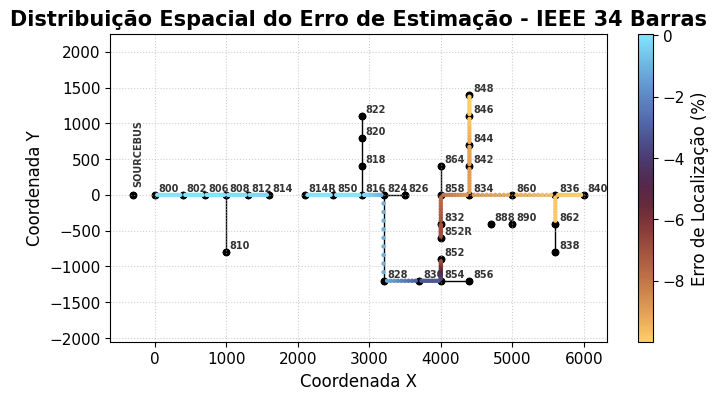

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CARREGAMENTO DOS DADOS ---
# Coordenadas das barras (enviadas por você)
df_coords = pd.read_csv(BASE_DIR / "data" / "34Bus" / "IEEE34_BusXY.csv", header=None, names=['Bus', 'X', 'Y'])
coords = {str(row['Bus']).lower(): (row['X'], row['Y']) for _, row in df_coords.iterrows()}

# Resultados da simulação (gerados anteriormente)
# df_res = pd.read_csv('result/localizacao_filtrada.csv', sep=';', decimal=',')

# --- 2. CONFIGURAÇÃO DO PLOT ---
plt.figure(figsize=(8, 4))
plt.rcParams["font.family"] = "DejaVu Sans"

# --- 3. DESENHAR A ESTRUTURA DA REDE (LINHAS CINZAS) ---
# Usamos a topologia mapeada para saber quem conecta com quem
for line_name, info in simulador.topology.line_data.items():
    b1, b2 = info['bus1'], info['bus2']
    if b1 in coords and b2 in coords:
        x_values = [coords[b1][0], coords[b2][0]]
        y_values = [coords[b1][1], coords[b2][1]]
        # plt.plot(x_values, y_values, color='lightgray', linewidth=1, zorder=1)
        plt.plot(x_values, y_values, color='black', linewidth=1, zorder=1)

bus_x = [coord[0] for coord in coords.values()]
bus_y = [coord[1] for coord in coords.values()]
plt.scatter(bus_x, bus_y, color='black', s=20, zorder=1, label='Barras (Nós)')

# --- 3.2 Desenhar as Barras/Nós ---
barras_rotacionadas = ['sourcebus']

for bus_name, (bx, by) in coords.items():
    # Desenha o ponto da barra
    plt.scatter(bx, by, color='black', s=20, zorder=1)
    
    rotacao = 0
    deslocamento_x = 50
    deslocamento_y = 50

    if bus_name in barras_rotacionadas:
        rotacao = 90
        # Dica: Quando você rotaciona o texto, às vezes ele fica em cima da linha.
        # Você pode ajustar o deslocamento X e Y especificamente para elas:
        deslocamento_x = 0
        deslocamento_y = 150

    # Adiciona o nome da barra com um pequeno deslocamento (ex: +50 unidades em X e Y)
    # ha='left' e va='bottom' ajudam a posicionar o texto para fora do ponto
    plt.text(bx + deslocamento_x, by + deslocamento_y, bus_name.upper(), 
             fontsize=7, 
             fontweight='bold',
             color='black',
             alpha=0.8,
             zorder=1,
             rotation=rotacao)

# Adiciona uma entrada manual na legenda para as barras, se desejar
plt.scatter([], [], color='black', s=40, label='Barras (Nós)')

# --- 4. PLOTAR OS ERROS (HEATMAP DE PONTOS) ---
results_df = localizador.df.copy()
# Filtrando os dados (mantendo a sua coluna 'r' do CSV antigo)
df_mapa = results_df[(results_df['tipo'] == 'abc') & (results_df['r'] == 0.0001)].copy()

x_faltas, y_faltas, erros = [], [], []

# Vamos iterar por cada linha única que teve faltas
for line_name in df_mapa['linha_faltosa'].unique():
    
    # Filtra o dataframe apenas para os 9 pontos desta seção de linha específica
    df_linha = df_mapa[df_mapa['linha_faltosa'] == line_name]
    line_info = simulador.topology.line_data.get(line_name)
    
    if not line_info: 
        continue
        
    b1, b2 = line_info['bus1'], line_info['bus2']
    
    if b1 in coords and b2 in coords:
        length_km = UnitConverter.to_km(line_info['length'], simulador.units)
        line_length_m = length_km * 1000.0

        # --- O SEGREDO DA CORREÇÃO ---
        # Como a distância absoluta do CSV antigo está dessincronizada da rede,
        # descobrimos a distância base da linha lendo a menor distância registrada nela.
        # Sabemos que a menor distância do seu passo representa 10% (0.1) da linha.
        dist_min_csv = df_linha['distancia'].min()
        base_csv = dist_min_csv - (0.1 * line_length_m)

        for _, row in df_linha.iterrows():
            # Agora o 'm' é calculado perfeitamente de 0.1 a 0.9 usando a base corrigida
            m = (row['distancia'] - base_csv) / line_length_m
            m = np.clip(m, 0, 1)

            # Interpolação geométrica nas coordenadas X e Y
            xf = coords[b1][0] + m * (coords[b2][0] - coords[b1][0])
            yf = coords[b1][1] + m * (coords[b2][1] - coords[b1][1])
            
            x_faltas.append(xf)
            y_faltas.append(yf)
            erros.append((row['erro_percentual']))

# Criar o scatter plot colorido pelo erro
sc = plt.scatter(x_faltas, y_faltas, c=erros, cmap='managua', s=10, edgecolors='none', zorder=2)

# --- 5. ESTÉTICA E BARRA DE CORES ---
# ... (mantenha o restante do seu código de estética original aqui)

# --- 5. ESTÉTICA E BARRA DE CORES ---
cbar = plt.colorbar(sc)
cbar.set_label('Erro de Localização (%)', fontsize=12)

plt.title('Distribuição Espacial do Erro de Estimação - IEEE 34 Barras', fontsize=15, fontweight='bold')
plt.xlabel('Coordenada X', fontsize=12)
plt.ylabel('Coordenada Y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Mantém a proporção da rede

plt.show()

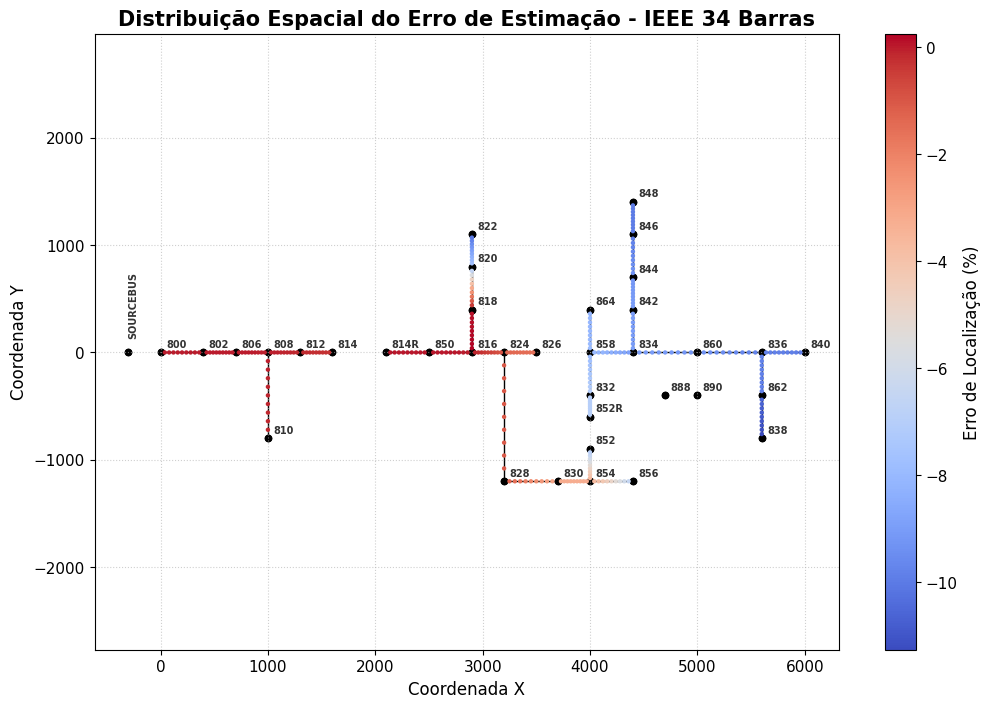

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CARREGAMENTO DOS DADOS ---
# Coordenadas das barras (enviadas por você)
df_coords = pd.read_csv(BASE_DIR / "data" / "34Bus" / "IEEE34_BusXY.csv", header=None, names=['Bus', 'X', 'Y'])
coords = {str(row['Bus']).lower(): (row['X'], row['Y']) for _, row in df_coords.iterrows()}

# Resultados da simulação (gerados anteriormente)
# df_res = pd.read_csv('result/localizacao_filtrada.csv', sep=';', decimal=',')

# --- 2. CONFIGURAÇÃO DO PLOT ---
plt.figure(figsize=(12, 8))
plt.rcParams["font.family"] = "DejaVu Sans"

# --- 3. DESENHAR A ESTRUTURA DA REDE (LINHAS CINZAS) ---
# Usamos a topologia mapeada para saber quem conecta com quem
for line_name, info in simulador.topology.line_data.items():
    b1, b2 = info['bus1'], info['bus2']
    if b1 in coords and b2 in coords:
        x_values = [coords[b1][0], coords[b2][0]]
        y_values = [coords[b1][1], coords[b2][1]]
        # plt.plot(x_values, y_values, color='lightgray', linewidth=1, zorder=1)
        plt.plot(x_values, y_values, color='black', linewidth=1, zorder=1)

bus_x = [coord[0] for coord in coords.values()]
bus_y = [coord[1] for coord in coords.values()]
plt.scatter(bus_x, bus_y, color='black', s=20, zorder=1, label='Barras (Nós)')

# --- 3.2 Desenhar as Barras/Nós ---
barras_rotacionadas = ['sourcebus']

for bus_name, (bx, by) in coords.items():
    # Desenha o ponto da barra
    plt.scatter(bx, by, color='black', s=20, zorder=1)
    
    rotacao = 0
    deslocamento_x = 50
    deslocamento_y = 50

    if bus_name in barras_rotacionadas:
        rotacao = 90
        # Dica: Quando você rotaciona o texto, às vezes ele fica em cima da linha.
        # Você pode ajustar o deslocamento X e Y especificamente para elas:
        deslocamento_x = 0
        deslocamento_y = 150

    # Adiciona o nome da barra com um pequeno deslocamento (ex: +50 unidades em X e Y)
    # ha='left' e va='bottom' ajudam a posicionar o texto para fora do ponto
    plt.text(bx + deslocamento_x, by + deslocamento_y, bus_name.upper(), 
             fontsize=7, 
             fontweight='bold',
             color='black',
             alpha=0.8,
             zorder=1,
             rotation=rotacao)

# Adiciona uma entrada manual na legenda para as barras, se desejar
plt.scatter([], [], color='black', s=40, label='Barras (Nós)')

# --- 4. PLOTAR OS ERROS (HEATMAP HÍBRIDO DE MÁXIMA COBERTURA) ---
results_df = localizador.df.copy()

# 1. Filtramos apenas pela resistência desejada (Sem filtrar o tipo ainda)
resistencia_alvo = 0.0001
df_res_alvo = results_df[results_df['r'] == resistencia_alvo].copy()

x_faltas, y_faltas, erros = [], [], []

# 2. Ordem de prioridade: O que o algoritmo deve tentar plotar primeiro
prioridade_faltas = ['abc', 'ab', 'bc', 'ac', 'at', 'bt', 'ct']

# Iteramos por CADA LINHA única simulada com essa resistência
for line_name in df_res_alvo['linha_faltosa'].unique():
    
    # Pega todos os dados simulados apenas para esta linha específica
    df_linha_completo = df_res_alvo[df_res_alvo['linha_faltosa'] == line_name]
    tipos_simulados = df_linha_completo['tipo'].unique()
    
    # 3. Descobre qual é a "maior" falta possível para essa linha
    tipo_escolhido = None
    for tipo in prioridade_faltas:
        if tipo in tipos_simulados:
            tipo_escolhido = tipo
            break
            
    # Se encontrou um tipo válido, isola os pontos de distância apenas dele
    if tipo_escolhido:
        df_linha = df_linha_completo[df_linha_completo['tipo'] == tipo_escolhido]
        line_info = simulador.topology.line_data.get(line_name)
        
        if line_info:
            b1, b2 = line_info['bus1'], line_info['bus2']
            if b1 in coords and b2 in coords:
                length_m = UnitConverter.to_km(line_info['length'], simulador.units) * 1000.0
                
                # Correção geométrica relativa para garantir que os pontos cubram a linha
                dist_min_csv = df_linha['distancia'].min()
                base_csv = dist_min_csv - (0.1 * length_m)

                for _, row in df_linha.iterrows():
                    m = (row['distancia'] - base_csv) / length_m
                    m = np.clip(m, 0, 1)

                    xf = coords[b1][0] + m * (coords[b2][0] - coords[b1][0])
                    yf = coords[b1][1] + m * (coords[b2][1] - coords[b1][1])
                    
                    x_faltas.append(xf)
                    y_faltas.append(yf)
                    erros.append(row['erro_percentual']) # Mantém o sinal real de erro

# Plotagem do gradiente de erro com escala divergente (Coolwarm)
sc = plt.scatter(x_faltas, y_faltas, c=erros, cmap='coolwarm', s=10, edgecolors='none', zorder=2)

# --- 5. ESTÉTICA E BARRA DE CORES ---
cbar = plt.colorbar(sc)
cbar.set_label('Erro de Localização (%)', fontsize=12)

plt.title('Distribuição Espacial do Erro de Estimação - IEEE 34 Barras', fontsize=15, fontweight='bold')
plt.xlabel('Coordenada X', fontsize=12)
plt.ylabel('Coordenada Y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Mantém a proporção da rede

plt.show()